2026-01-25 08-28-13
Outputs will be written to: results/run_2026-01-25 08-28-13
Saved a copy of the config : results/run_2026-01-25 08-28-13/config_copy.yaml
Inputs shape: (42, 4)
Outputs shape: (42,)
First 20 rows of raw data:
    hype-para--1  hype-para-2  hype-para-3  hype-para-4  opt-place-score  source
27      0.577766     0.428772     0.425826     0.249007        -4.025542    file
36      0.572134     0.415866     0.465114     0.491781        -4.550363  week-7
30      0.469388     0.448980     0.469388     0.204082        -4.620232  week-1
38      0.573921     0.509823     0.408512     0.282146        -4.847336  week-9
31      0.515152     0.484848     0.363636     0.181819        -4.939960  week-2
32      0.515152     0.484848     0.363636     0.181819        -5.313374  week-3
24      0.326076     0.472367     0.453192     0.105887        -6.702089    file
34      0.343612     0.592249     0.651353     0.444513        -7.221570  week-5
35      0.445393     0.174795     0.339088 

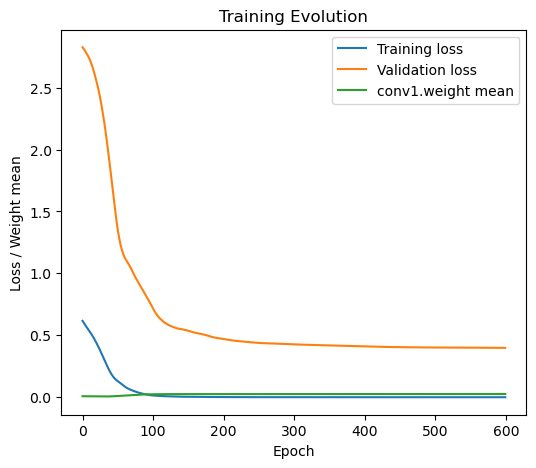

sample_strategy=sobol, Final sample shape: (1048576, 4)
⚠️ No filtering applied to candidate grid
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.59059748, 0.50314445, 0.45923958, 0.29323496]), 'score': 0.7985634924950367, 'dim': 4, 'predicted_y': -3.4796658, 'improvement_over_input_model': 0.34780598, 'distance_to_best_input': 0.054945064332779736, 'distance_to_real_best_input': 0.09364031736212731, 'best_input_x': array([0.573921, 0.509823, 0.408512, 0.282146]), 'best_input_pred': -3.8274717, 'real_best_x': array([0.57776561, 0.42877174, 0.42582587, 0.24900741]), 'real_best_y': -4.025542281908162}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.47871654, 0.47572065, 0.47484402, 0.3840793 ]), 'score': 0.35094215437820653, 'dim': 4, 'predicted_y': -3.6285772, 'improvement_over_input_model': 0.1988945, 'distance_to_best_input': 0.15816825388225747, 'distance_to_real_best_input': 0.1807266296487254, 'best_input_x': array([0.573921,

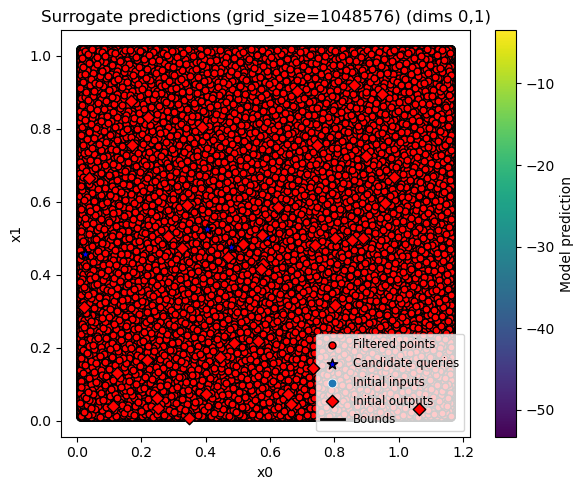

Saved dataframe to: results/run_2026-01-25 08-28-13/df_grid_1048576_stride8_None_max_raw_lr0.001_ep600.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.02701853, 0.45630816, 0.46695591, 0.43877137]), 'score': 2.1956931509069313, 'dim': 4, 'predicted_y': -5.674735, 'improvement_over_input_model': -1.8472633, 'distance_to_best_input': 0.5743808377112118, 'distance_to_real_best_input': 0.5846217963489082, 'best_input_x': array([0.573921, 0.509823, 0.408512, 0.282146]), 'best_input_pred': -3.8274717, 'real_best_x': array([0.57776561, 0.42877174, 0.42582587, 0.24900741]), 'real_best_y': -4.025542281908162}
    hype-para--1  hype-para-2  hype-para-3  hype-para-4  opt-place-score   source  opt-place-score-scaled
0       0.027019     0.456308     0.466956     0.438771         2.195693   week-x               10.000000
1       0.027019     0.456308     0.466956     0.438771         1.813556   week-x                8.259604
2       0.404212     0.524028     0.448303  

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))